In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
import pymc as pm # PyMC for fitting Bayesian Models
import arviz as az
from scipy.stats import chi2, invgamma, norm, multivariate_normal


In [2]:
df = pd.read_parquet("../../eda/misc/all_info_embedded_trimmed.parquet")

In [3]:
df.shape

(30847, 20)

In [4]:
df.head()

,bioguide_id,bill_id,vote,id,birthYear,deathYear,num_terms,positions,states,parties,congress_range,nominate_dim1_x,nominate_dim2_x,govtrack_ideology_score_x,nominate_dim1_y,nominate_dim2_y,govtrack_ideology_score_y,state_num,bill_des_embed,bio_embed
162830,P000513,S12,0,P000513,1942.0,NaN,11,"['Representative', 'Senator']",SD,Republican,94-104,0.213,-0.259,NaN,0.213,-0.259,NaN,31,"[-0.044650908559560776, 0.04374602809548378, 0...","[-0.11883838474750519, 0.04829862713813782, -0..."
92027,D000407,S2884,0,D000407,1932.0,2017.0,18,['Senator'],NM,Republican,93-110,0.257,-0.247,NaN,0.257,-0.247,NaN,23,"[-0.01395636796951294, 0.053724903613328934, 0...","[-0.11883838474750519, 0.04829862713813782, -0..."
165442,R000295,S2166,1,R000295,1939.0,NaN,6,['Senator'],VA,Democrat,101-106,-0.200,-0.040,NaN,-0.200,-0.040,NaN,47,"[-0.031419787555933, 0.04570649564266205, 0.09...","[0.017814278602600098, -0.015489867888391018, ..."
577401,T000317,HR4101,1,T000317,1951.0,NaN,10,"['Representative', 'Senator']",NJ,Democrat,98-107,-0.262,-0.118,NaN,-0.262,-0.118,NaN,44,"[-0.028057817369699478, -0.021678149700164795,...","[-0.11883838474750519, 0.04829862713813782, -0..."
402684,D000407,HR4,1,D000407,1932.0,2017.0,18,['Senator'],NM,Republican,93-110,0.257,-0.247,NaN,0.257,-0.247,NaN,23,"[-0.07578570395708084, 0.06835657358169556, 0....","[-0.11883838474750519, 0.04829862713813782, -0..."


In [5]:
from sklearn.decomposition import PCA
import numpy as np

# Stack embeddings into a matrix
X = np.vstack(df['bill_des_embed'].values)

pca = PCA(n_components=1)
df['bill_des_embed_score'] = pca.fit_transform(X)

In [6]:
# Stack embeddings into a matrix

# Stack embeddings into a matrix
X = np.vstack(df['bill_des_embed'].values)

pca = PCA(n_components=1)
df['bill_des_embed_score'] = pca.fit_transform(X)
X = np.vstack(df['bio_embed'].values)

pca = PCA(n_components=1)
df['bio_embed_score'] = pca.fit_transform(X)

df['parties'] = df['parties'].astype('category')
df['parties_nums'] = df['parties'].cat.codes

df_model = df[df['vote'].isin([0, 1])].copy()

In [7]:
df.head()

,bioguide_id,bill_id,vote,id,birthYear,deathYear,num_terms,positions,states,parties,...,nominate_dim2_x,govtrack_ideology_score_x,nominate_dim1_y,nominate_dim2_y,govtrack_ideology_score_y,state_num,bill_des_embed,bio_embed,bill_des_embed_score,bio_embed_score
162830,P000513,S12,0,P000513,1942.0,NaN,11,"['Representative', 'Senator']",SD,Republican,...,-0.259,NaN,0.213,-0.259,NaN,31,"[-0.044650908559560776, 0.04374602809548378, 0...","[-0.11883838474750519, 0.04829862713813782, -0...",0.206864,0.744168
92027,D000407,S2884,0,D000407,1932.0,2017.0,18,['Senator'],NM,Republican,...,-0.247,NaN,0.257,-0.247,NaN,23,"[-0.01395636796951294, 0.053724903613328934, 0...","[-0.11883838474750519, 0.04829862713813782, -0...",0.235035,0.744168
165442,R000295,S2166,1,R000295,1939.0,NaN,6,['Senator'],VA,Democrat,...,-0.040,NaN,-0.200,-0.040,NaN,47,"[-0.031419787555933, 0.04570649564266205, 0.09...","[0.017814278602600098, -0.015489867888391018, ...",0.170534,-0.434225
577401,T000317,HR4101,1,T000317,1951.0,NaN,10,"['Representative', 'Senator']",NJ,Democrat,...,-0.118,NaN,-0.262,-0.118,NaN,44,"[-0.028057817369699478, -0.021678149700164795,...","[-0.11883838474750519, 0.04829862713813782, -0...",-0.535571,0.744168
402684,D000407,HR4,1,D000407,1932.0,2017.0,18,['Senator'],NM,Republican,...,-0.247,NaN,0.257,-0.247,NaN,23,"[-0.07578570395708084, 0.06835657358169556, 0....","[-0.11883838474750519, 0.04829862713813782, -0...",-0.008012,0.744168


In [8]:
df['parties'].unique()

<ArrowStringArray>
[               'Republican',                  'Democrat',
               'Independent',    'Democrat', 'Republican',
   'Democrat', 'Independent', 'Republican', 'Independent']
Length: 6, dtype: str

In [9]:
df['parties'] = df['parties'].astype('category')
df['parties_nums'] = df['parties'].cat.codes


In [10]:
df.head()

,bioguide_id,bill_id,vote,id,birthYear,deathYear,num_terms,positions,states,parties,...,govtrack_ideology_score_x,nominate_dim1_y,nominate_dim2_y,govtrack_ideology_score_y,state_num,bill_des_embed,bio_embed,bill_des_embed_score,bio_embed_score,parties_nums
162830,P000513,S12,0,P000513,1942.0,NaN,11,"['Representative', 'Senator']",SD,Republican,...,NaN,0.213,-0.259,NaN,31,"[-0.044650908559560776, 0.04374602809548378, 0...","[-0.11883838474750519, 0.04829862713813782, -0...",0.206864,0.744168,4
92027,D000407,S2884,0,D000407,1932.0,2017.0,18,['Senator'],NM,Republican,...,NaN,0.257,-0.247,NaN,23,"[-0.01395636796951294, 0.053724903613328934, 0...","[-0.11883838474750519, 0.04829862713813782, -0...",0.235035,0.744168,4
165442,R000295,S2166,1,R000295,1939.0,NaN,6,['Senator'],VA,Democrat,...,NaN,-0.200,-0.040,NaN,47,"[-0.031419787555933, 0.04570649564266205, 0.09...","[0.017814278602600098, -0.015489867888391018, ...",0.170534,-0.434225,0
577401,T000317,HR4101,1,T000317,1951.0,NaN,10,"['Representative', 'Senator']",NJ,Democrat,...,NaN,-0.262,-0.118,NaN,44,"[-0.028057817369699478, -0.021678149700164795,...","[-0.11883838474750519, 0.04829862713813782, -0...",-0.535571,0.744168,0
402684,D000407,HR4,1,D000407,1932.0,2017.0,18,['Senator'],NM,Republican,...,NaN,0.257,-0.247,NaN,23,"[-0.07578570395708084, 0.06835657358169556, 0....","[-0.11883838474750519, 0.04829862713813782, -0...",-0.008012,0.744168,4


In [12]:
df_model = df[df['vote'].isin([0, 1])].copy()

In [14]:
df_model.columns

Index(['bioguide_id', 'bill_id', 'vote', 'id', 'birthYear', 'deathYear',
       'num_terms', 'positions', 'states', 'parties', 'congress_range',
       'nominate_dim1_x', 'nominate_dim2_x', 'govtrack_ideology_score_x',
       'nominate_dim1_y', 'nominate_dim2_y', 'govtrack_ideology_score_y',
       'state_num', 'bill_des_embed', 'bio_embed', 'bill_des_embed_score',
       'bio_embed_score', 'parties_nums'],
      dtype='str')

Acceptance rate: 0.26%
Test accuracy: 62.54%


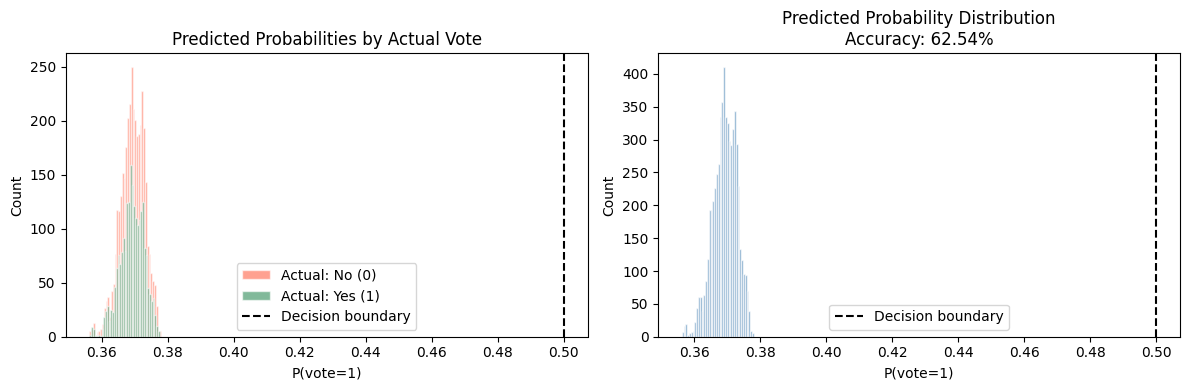

In [22]:
import numpy as np
from scipy.special import expit
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# ── DATA ──────────────────────────────────────────────────────────────────────
y = df_model['vote'].values
X_bill = df_model['bill_des_embed_score'].values
X_bio  = df_model['bio_embed_score'].values
X_year = df_model['birthYear'].values
party  = df_model['parties_nums'].values
state  = df_model['state_num'].values
n_party = df_model['parties_nums'].nunique()
n_params = 4 + n_party + 50

# ── LOG PRIOR ─────────────────────────────────────────────────────────────────
def log_prior(params):
    lp  = -0.5 * params[0]**2                      # α
    lp += -0.5 * params[1]**2                      # β_bill
    lp += -0.5 * params[2]**2                      # β_bio
    lp += -0.5 * params[3]**2                      # β_year
    lp += np.sum(-0.5 * params[4:4+n_party]**2)    # β_party
    lp += np.sum(-0.5 * params[4+n_party:]**2)     # β_state
    return lp

# ── LOG LIKELIHOOD (subset-able) ──────────────────────────────────────────────
def log_likelihood(params, idx=None):
    if idx is None:
        idx = np.arange(len(y))
    α, β_bill, β_bio, β_year = params[:4]
    β_party = params[4:4+n_party]
    β_state = params[4+n_party:]

    logit_p = (α +
               β_party[party[idx]] +
               β_state[state[idx]] +
               β_bill * X_bill[idx] +
               β_bio  * X_bio[idx]  +
               β_year * X_year[idx])

    p = np.clip(expit(logit_p), 1e-10, 1 - 1e-10)
    return np.sum(y[idx] * np.log(p) + (1 - y[idx]) * np.log(1 - p))

def log_posterior(params, idx=None):
    return log_prior(params) + log_likelihood(params, idx)

# ── METROPOLIS-HASTINGS ───────────────────────────────────────────────────────
def metropolis_hastings(n_samples=5000, step_size=0.005, train_idx=None):
    samples  = np.zeros((n_samples, n_params))
    current  = np.zeros(n_params)
    current_lp = log_posterior(current, train_idx)
    accepted = 0

    for i in range(n_samples):
        proposal   = current + np.random.normal(0, step_size, n_params)
        proposal_lp = log_posterior(proposal, train_idx)

        if np.log(np.random.uniform()) < proposal_lp - current_lp:
            current    = proposal
            current_lp = proposal_lp
            accepted  += 1

        samples[i] = current

    acceptance_rate = accepted / n_samples
    print(f"Acceptance rate: {acceptance_rate:.2%}")
    return samples, acceptance_rate

# ── PREDICT ───────────────────────────────────────────────────────────────────
def predict(posterior_samples, idx):
    α       = posterior_samples[:, 0].mean()
    β_bill  = posterior_samples[:, 1].mean()
    β_bio   = posterior_samples[:, 2].mean()
    β_year  = posterior_samples[:, 3].mean()
    β_party = posterior_samples[:, 4:4+n_party].mean(axis=0)
    β_state = posterior_samples[:, 4+n_party:].mean(axis=0)

    logit_p = (α +
               β_party[party[idx]] +
               β_state[state[idx]] +
               β_bill * X_bill[idx] +
               β_bio  * X_bio[idx]  +
               β_year * X_year[idx])
    return expit(logit_p)

from sklearn.model_selection import train_test_split

# split indices
train_idx, test_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42
)

# run sampler on training data
n_samples = 5000
burnin = int(0.18 * n_samples)

samples, _ = metropolis_hastings(n_samples=n_samples, step_size=0.005, train_idx=train_idx)
posterior = samples[burnin:]

# predict on test data
probs = predict(posterior, test_idx)
preds = (probs >= 0.5).astype(int)
acc = (preds == y[test_idx]).mean()
print(f"Test accuracy: {acc:.2%}")

# ── PLOTS ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# predicted probability distribution by actual class
axes[0].hist(probs[y[test_idx] == 0], bins=40, alpha=0.6, label='Actual: No (0)', color='tomato', edgecolor='white')
axes[0].hist(probs[y[test_idx] == 1], bins=40, alpha=0.6, label='Actual: Yes (1)', color='seagreen', edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', label='Decision boundary')
axes[0].set_title("Predicted Probabilities by Actual Vote")
axes[0].set_xlabel("P(vote=1)")
axes[0].set_ylabel("Count")
axes[0].legend()

# overall predicted probability distribution
axes[1].hist(probs, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(0.5, color='black', linestyle='--', label='Decision boundary')
axes[1].set_title(f"Predicted Probability Distribution\nAccuracy: {acc:.2%}")
axes[1].set_xlabel("P(vote=1)")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()
